                                PPROJECT TITLE 
        Promotion Strategy Optimization in Retail Pharmacy 
                     Case Study: COMPANY X(Feb – May 2026)

Excetive  Summary:

This project evaluates the efficiency of promotional strategies within a retail pharmacy environment.

 I focused on identifying categories that are heavily discounted without clear strategic justification, as well as seasonal patterns in discounting behavior.
 
Due to the absence of sales volume data, I reframed the analysis to assess promotional intensity and potential margin risk, using discount depth as a proxy. The goal was to highlight areas where the business may be over-discounting and recommend tighter promotion control to protect profitability.

The outcome is a decision-support framework for improving promotional governance and reducing unnecessary margin exposure.

Project Objectives:

detecting  inefficient promotion structures, and recommend strategies to optimize profitability while maintaining customer traffic.

Nahdi Pharmacy operates in a highly competitive, price-sensitive environment, where promotions are a key lever to:

Increase store traffic
Expand basket size
Defend market share against competitors

However, without robust optimization, promotions can create a false sense of growth—increasing revenue while silently eroding profitability.

1.Promotion Strategy Diagnostics

-Identifing dominant promotion types (e.g., % discount, bundle, BOGO)

-Evaluating distribution across categories and brands

-Identify categories with excessive promotional exposure

2.Discount Depth analysis

3.Evaluation of Promotion Effectiveness by Product Category

4.Gain Made by Customers vs Loss to Company


    -Customer savings (discount captured)

    -Company revenue sacrificed


Who benefits more — the customer or the business?




Data Constraints Acknowledgment 

Due to the absence of cost and customer-level data, the analysis focuses on proxy indicators of profitability, including:




If provided with a complete dataset, I would reposition the analysis into two strategic pillars: product-centric performance and customer-centric behavior, ensuring both commercial impact and long-term sustainability are addressed.

On the product (or promotion) side, I would reframe the evaluation of promotional effectiveness around three core financial metrics: incremental sales uplift, margin impact, and promotion ROI. The first step would be to construct a robust baseline model to estimate expected sales in the absence of promotions, enabling a clear measurement of true incremental uplift. I would then quantify the margin trade-off by assessing whether the additional revenue generated sufficiently compensates for the discount-driven margin erosion. Building on this, I would implement a structured decision framework (e.g., a performance matrix) to segment promotions into high-performing, neutral, and value-destructive categories. This would allow the business to systematically scale profitable promotions, optimize borderline campaigns, and eliminate those that fail to generate sustainable value.

On the customer side, I would redesign the analysis using an RFM  framework to develop a deeper understanding of customer behavior and loyalty dynamics. This segmentation would help identify high-value loyal customers, promotion-dependent segments, and those at risk of churn. More importantly, it would enable the business to assess price sensitivity and promotion dependency, highlighting which customer groups are likely to disengage if discounts are reduced or removed. These insights can then inform more targeted and personalized promotion strategies, reducing unnecessary discounting while preserving customer retention and lifetime value.

Together, these two perspectives create a more holistic strategy while balancing short-term promotional gains with long-term customer equity and profitability.

In [88]:
import pandas as pd
import numpy as np

import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px





In [89]:
def load_files(folder_path):

    df_list = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis", file)

        try:

            if file.endswith(".csv"):
                df = pd.read_csv(file_path)

            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            elif file.endswith('.js'):
                df=pd.read_json(file_path)
            elif file.endswith('.txt'):
                df=pd.read_table(file_path)

            else:
                continue

            df['source_file'] = file
            df_list.append(df)

            print(f"{file} loaded successfully")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return pd.concat(df_list, ignore_index=True)


In [90]:
df = load_files(r"C:\Users\PAVILION PLUS\Desktop\COMPANY_X   analysis")
df

APRIL.xlsx loaded successfully
FEBRUARY.xlsx loaded successfully
MARCH.xlsx loaded successfully
MAY.xlsx loaded successfully


,Division,Department,Category,Item Brand,Period,Channel,Group_Code,ITEM,English Description,OFFER TYPE,Price with VAT,Promo Price with VAT,Saving,Depth%,START_DATE,END_DATE,source_file,Hero
0,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103184367,Christian Dior miss dior EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
1,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183866,Christian Dior sauvage Perfume 200 ml,Direct_Discount,1054.57,843.70,210.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
2,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183807,Christian Dior pure poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
3,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103181908,Christian Dior dior homme intense EDP150 ml,Direct_Discount,725.86,580.70,145.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx,NaN
4,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183129,Christian Dior hypnotic poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28646,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476747,Bw Mega Pro Protein Bar Waffle With Chocolate ...,BUY 1 GET 1 WITH PERCENT OFF 50,30.03,22.55,7.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
28647,WELLNESS,NUTRACEUTICALS AND NUTRITION,HEALTHY NUTRITION,True Honey,Full,BM only,1_230589,103379017,Manuka Truehoney Rare Harvest Mgo 2050 - 230 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,10041.65,7531.25,2510.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
28648,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Eric Favre,Full,BM only,1_230589,102028709,Eric Favre Mass Gainer Vanille 3kg,BUY 1 GET 1 WITH PERCENT OFF 50,401.10,300.85,100.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL
28649,WELLNESS,NUTRACEUTICALS AND NUTRITION,SPORTS AND FITNESS,Born Winner,Full,BM only,1_230589,102476712,Bw Keto Bar Italian Creme 60 Gm,BUY 1 GET 1 WITH PERCENT OFF 50,27.38,20.55,6.0,NaN,2026-05-01,2026-05-31,MAY.xlsx,PL


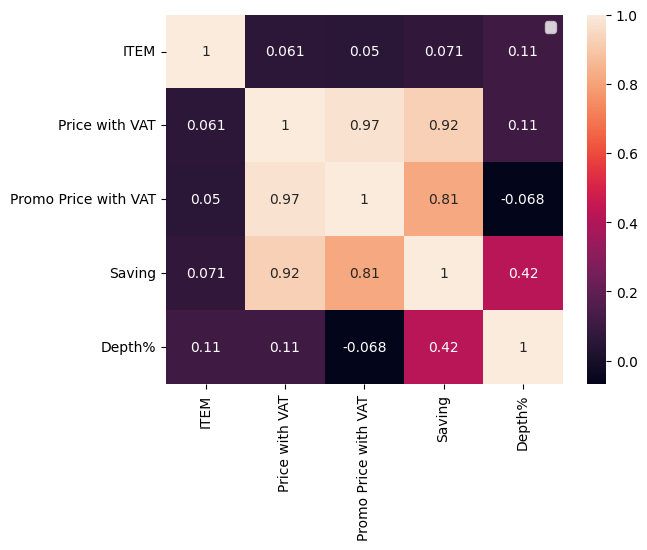

In [91]:
data_corr=df.corr(numeric_only=True)
sns.heatmap(data_corr,annot=True)
plt.legend('numerical correction')
plt.show()

In [92]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

FEATURE ENGINEERING

In [93]:
#Promotion Duration
df['Promo_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.days

#Discount Percentage
df['Calculated_Discount'] = (df['Price with VAT'] - df['Promo Price with VAT']) / df['Price with VAT']*100

#Price Reduction
df['Price_Reduction'] = df['Price with VAT'] - df['Promo Price with VAT']

#Discount Depth
df['Discount_Depth'] = df['Saving'] / df['Price with VAT'] 

#Price Category
df['Price_Category'] = pd.qcut(df['Price with VAT'], q=4, labels=['Low','Medium','High','Premium'])

#calculated distance category
df['Calculated_Discount_catrgory']  = pd.qcut(df['Calculated_Discount'], q=3, labels=['Low','High','Premium'])

#Promotion Month
df['Promo_Month'] = df['START_DATE'].dt.month



#"corrected_Depth%"
mapping = {
    'BUY 2 GET 1 FREE ': 1,
    'BUY 1 GET 1 FREE ': 1,
    'BUY 2 GET 2 FREE ':2,
    'BUY 1 GET 1 WITH PERCENT OFF 30':.30, 
    'BUY 1 GET 1 WITH PERCENT OFF 40':.40,
    'BUY 1 GET 1 WITH PERCENT OFF 50':.50,
    'BUY 1 GET 1 WITH PERCENT OFF 60':.60,
    'BUY 1 GET 1 WITH PERCENT OFF 70':.70,
    'BUY 1 GET 2 FREE ':2,
    '(B/G) BUY 2 GET 1 FREE ':1,
    'BUY 1 GET 1 WITH PERCENT OFF 70': .30

}

df["corrected_Depth%"] = df.apply( lambda row: mapping[row["OFFER TYPE"]] if row["OFFER TYPE"] in mapping else row["Depth%"], axis=1)

# Promotion Risk Score
df['Promo_Risk_Score'] = df['corrected_Depth%'] * df['Promo_Duration']

#LABELS
mapping = {
    'Accez':'PL',
    'Active Go':'PL',
    'Alfoshan':'PL',
    'ALmisan':'PL', 
    'AURI':'PL',
    'Babygee':'PL',
    'Babywell':'PL',
    'Beatswell':'PL',
    'Bibi':'PL',
    'Bio-Synergy':'PL',
    'Blade':'PL',
    'Body Spa':'PL',
    'BODYLICIOUS':'PL',
    'Boutique':'PL',
    'Citizen':'PL',
    'Clary':'PL',
    'Clevie':'PL',
    'Clevie Derma':'PL',
    'Connect':'PL',
    'COXIR':'PL',
    'Creigtons':'PL',
    'Davids':'PL',
    'Emotion':'PL',
    'Eric Favre':'PL',
    'Febella':'PL',
    'First Aids Kit':'PL',
    'Footness':'PL',
    'Fragrances For Her':'PL',
    'Fruit Works':'PL',
    'Gamar':'PL',
    'Grit':'PL',
    'I Kuzma':'PL',
    'Kaiyang':'PL',
    'Keller':'PL',
    'Killys':'PL',
    'Mades':'PL',
    'Martini':'PL',
    'Medex':'PL',
    'Molfix':'PL',
    'Movera':'PL',
    'Movera Ortho':'PL',
    'Movera Sport':'PL',
    'MUVU':'PL',
    'Nahdi':'PL',
    'NUTSHELL':'PL',
    'OE':'PL',
    'OnCall':'PL',
    'Orex':'PL',
    'Parsa':'PL',
    'Parsa Beauty':'PL',
    'Qure':'PL',
    'Rosal':'PL',
    'Sanotact':'PL',
    'Shadez':'PL',
    'True Honey':'PL',
    'Velveta':'PL',
    'Viora':'PL',
    'Yunmai':'PL',
    'Yuwell':'PL',
    'ZAK':'PL'

}
df["LABELS"] = df.apply( lambda row: mapping[row["Item Brand"]] if row["Item Brand"] in mapping else 'OTHERS', axis=1)


DETAILING OF OBJECTIVES

# OBJECTIVE 1.Promotion Strategy Diagnostics

OFFER TYPE
Direct_Discount                    28.215420
BUY 2 GET 1 FREE                   23.615232
BUY 1 GET 1 FREE                   14.083278
BUY 1 GET 1 WITH PERCENT OFF 50    11.929776
BUY 1 GET 1 WITH PERCENT OFF 40    11.828557
BUY 2 GET 2 FREE                    7.046874
BUY 1 GET 1 WITH PERCENT OFF 30     2.024362
BUY 1 GET 2 FREE                    0.603818
BUY 1 GET 1 WITH PERCENT OFF 60     0.558445
(B/G) BUY 2 GET 1 FREE              0.059335
BUY 1 GET 1 WITH PERCENT OFF 70     0.034903
Name: proportion, dtype: float64


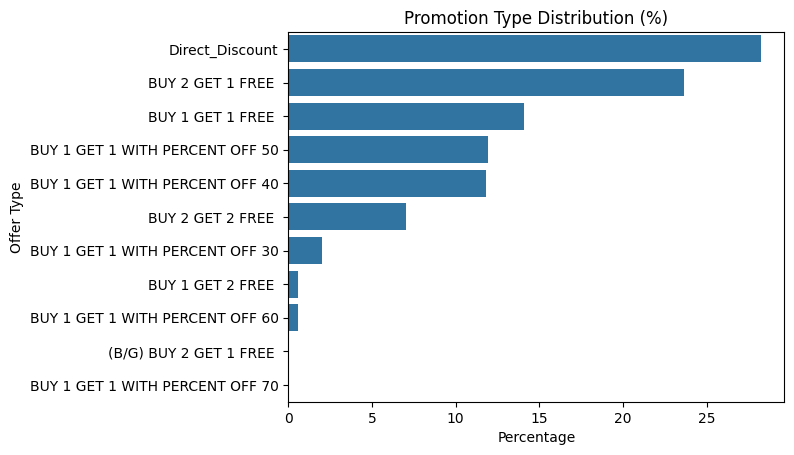

In [94]:
#1.1 Dominant Promotion Types
promo_dist = df['OFFER TYPE'].value_counts(normalize=True) * 100

print(promo_dist)

sns.barplot(x=promo_dist.values, y=promo_dist.index)
plt.title("Promotion Type Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("Offer Type")
plt.show()

In [95]:
#1.2
promo_dist_month = df.groupby('Promo_Month')['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month

Promo_Month  OFFER TYPE                     
2            BUY 2 GET 1 FREE                   27.146320
             BUY 2 GET 2 FREE                   24.837352
             Direct_Discount                    20.653145
             BUY 1 GET 1 FREE                   19.874984
             BUY 1 GET 1 WITH PERCENT OFF 50     5.931879
             BUY 1 GET 1 WITH PERCENT OFF 30     0.650593
             BUY 1 GET 1 WITH PERCENT OFF 60     0.331675
             BUY 1 GET 2 FREE                    0.306162
             (B/G) BUY 2 GET 1 FREE              0.140324
             BUY 1 GET 1 WITH PERCENT OFF 70     0.127567
3            Direct_Discount                    30.292490
             BUY 1 GET 1 WITH PERCENT OFF 40    25.849802
             BUY 1 GET 1 WITH PERCENT OFF 50    18.134387
             BUY 2 GET 1 FREE                   16.079051
             BUY 1 GET 1 FREE                    8.537549
             BUY 1 GET 2 FREE                    0.474308
             BUY 1 GET 1 WI

In [96]:
#1.3
promo_dist_month_labels = df.groupby(['LABELS','Promo_Month'])['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month_labels

LABELS  Promo_Month  OFFER TYPE                     
OTHERS  2            BUY 2 GET 1 FREE                   31.775422
                     BUY 2 GET 2 FREE                   29.072719
                     Direct_Discount                    18.605346
                     BUY 1 GET 1 FREE                   12.154696
                     BUY 1 GET 1 WITH PERCENT OFF 50     6.809019
                     BUY 1 GET 1 WITH PERCENT OFF 30     0.761535
                     BUY 1 GET 1 WITH PERCENT OFF 60     0.388234
                     BUY 1 GET 2 FREE                    0.358369
                     (B/G) BUY 2 GET 1 FREE              0.074660
        3            BUY 1 GET 1 WITH PERCENT OFF 40    31.273910
                     Direct_Discount                    29.648049
                     BUY 2 GET 1 FREE                   19.452946
                     BUY 1 GET 1 FREE                    9.429992
                     BUY 1 GET 1 WITH PERCENT OFF 50     8.856159
                     BU

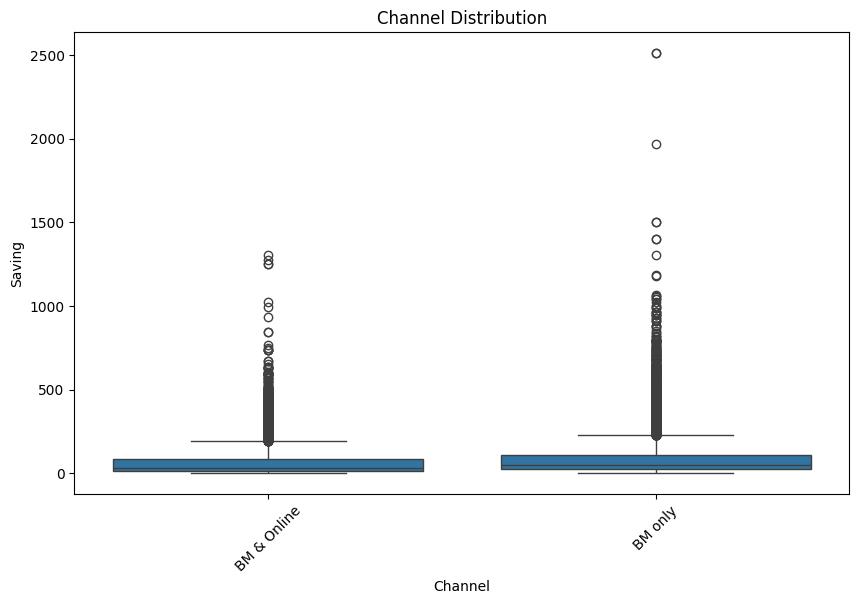

In [97]:
#1.4
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Channel', y='Saving')
plt.title("Channel Distribution")
plt.xticks(rotation=45)
plt.show()

In [98]:
#1.5 Distribution Across Categories & Brands

category_promo = pd.crosstab(df['Category'], df['OFFER TYPE'], normalize='index') * 100
brand_promo = pd.crosstab(df['Item Brand'], df['OFFER TYPE'], normalize='index') * 100



In [99]:
#1.6 Over-Reliance on Margin-Eroding Promotions

high_discount_threshold = df['corrected_Depth%'].quantile(0.75)

high_discount_ratio = (
    df[df['corrected_Depth%'] > high_discount_threshold]
    .groupby('Category')
    .size() / df.groupby('Category').size()
).fillna(0)

print(high_discount_ratio.sort_values(ascending=False))

Category
NAILS                      0.482618
MAKEUP                     0.267418
BEAUTY SKIN CARE           0.186485
HAIR TREATMENT             0.132827
HAIR COLOR                 0.093023
DERMO SKIN CARE            0.092002
HAIR REMOVALS              0.043860
PAIN MANAGEMENT            0.043478
SPORTS AND FITNESS         0.037915
MEN GROOMING               0.035714
GENERAL HEALTH             0.031568
WOMEN HEALTH               0.028264
HAND HYGIENE               0.025522
MEN HEALTH                 0.023649
BABY TOILETRIES            0.019835
INTIMATE HYGIENE           0.014563
HEALTHY NUTRITION          0.010453
DEODORANTS                 0.009112
REGULAR SKIN CARE          0.003674
DAILY HAIR CARE            0.002874
BODY MOISTURIZERS          0.002347
BEAUTY ACCESSORIES         0.001878
BODY FRESHENERS            0.000000
BABY WIPES                 0.000000
BREATH FRESHENER           0.000000
BODY SUPPORT               0.000000
BABY MILK                  0.000000
BABY FOOD          

In [100]:
#1.7  CATEGORY-LEVEL ANALYSIS

category_analysis = df.groupby('Category').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean',
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Promo_Frequency'}).reset_index().sort_values(by='Promo_Risk_Score', ascending=False)

category_analysis 

,Category,corrected_Depth%,Promo_Risk_Score,Promo_Frequency
44,NAILS,1.422494,39.295796,489
37,MAKEUP,1.111806,30.837173,2397
39,MEN GROOMING,0.896429,26.067857,56
31,HOME HYGIENE,0.900000,24.800000,10
29,HAND HYGIENE,0.851393,24.439361,431
17,DERMO SKIN CARE,0.840813,24.177400,3826
26,HAIR COLOR,0.855349,23.725581,215
52,SANITARY CARE,0.812088,23.120879,91
12,CLEAN HAIR CARE,0.791736,23.095886,121
25,GENERAL HEALTH,0.786730,23.020865,1869


In [101]:
# Sort by risk
category_analysis = category_analysis.sort_values(by='Promo_Risk_Score', ascending=False)

print("\n=== CATEGORY PROMOTION ANALYSIS ===")
print(category_analysis.head(10))


=== CATEGORY PROMOTION ANALYSIS ===
           Category  corrected_Depth%  Promo_Risk_Score  Promo_Frequency
44            NAILS          1.422494         39.295796              489
37           MAKEUP          1.111806         30.837173             2397
39     MEN GROOMING          0.896429         26.067857               56
31     HOME HYGIENE          0.900000         24.800000               10
29     HAND HYGIENE          0.851393         24.439361              431
17  DERMO SKIN CARE          0.840813         24.177400             3826
26       HAIR COLOR          0.855349         23.725581              215
52    SANITARY CARE          0.812088         23.120879               91
12  CLEAN HAIR CARE          0.791736         23.095886              121
25   GENERAL HEALTH          0.786730         23.020865             1869


# OBJECTIVE 2.Discount Depth 

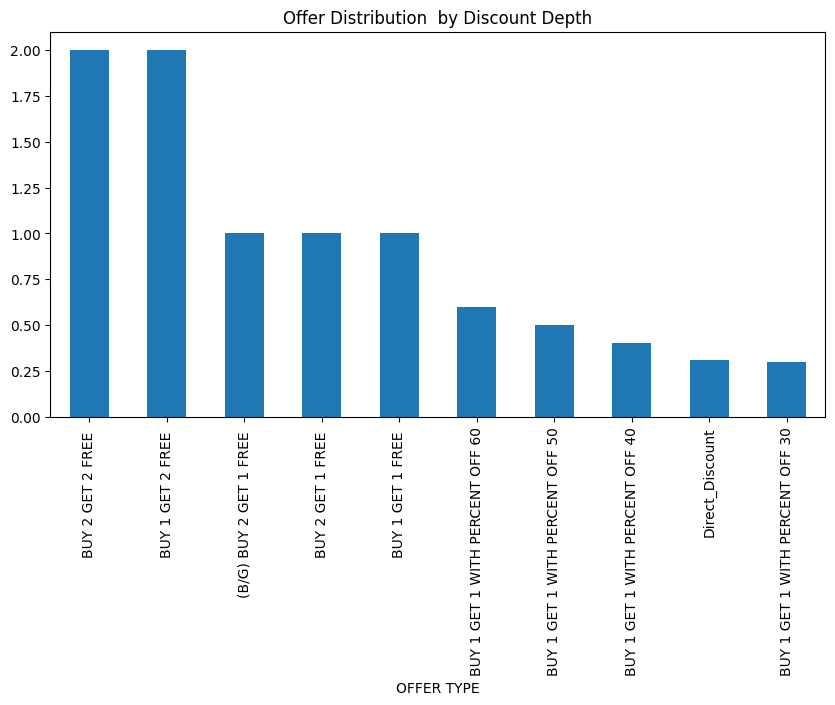

In [102]:
#2.1 discounting depth as per offer type
offer_distribution = (
    df.groupby('OFFER TYPE')['corrected_Depth%']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

offer_distribution.plot(kind='bar', figsize=(10,5), title='Offer Distribution  by Discount Depth')
plt.show()

In [103]:
#2.1 IDENTIFY OVER-PROMOTED CATEGORIES
# Thresholds 
high_discount_threshold = df['corrected_Depth%'].quantile(0.75)
high_frequency_threshold = category_analysis['Promo_Frequency'].quantile(0.75)

category_analysis['Risk_Level'] = np.where(
    (category_analysis['corrected_Depth%'] > high_discount_threshold) &
    (category_analysis['Promo_Frequency'] > high_frequency_threshold),
    'Critical',
    np.where(
        (category_analysis['corrected_Depth%'] > high_discount_threshold),
        'Moderate',
        'Low'
    )
)

print("\n=== RISK CLASSIFICATION ===")
print(category_analysis[['Category', 'Risk_Level']].head(10))





=== RISK CLASSIFICATION ===
           Category Risk_Level
44            NAILS   Critical
37           MAKEUP   Critical
39     MEN GROOMING        Low
31     HOME HYGIENE        Low
29     HAND HYGIENE        Low
17  DERMO SKIN CARE        Low
26       HAIR COLOR        Low
52    SANITARY CARE        Low
12  CLEAN HAIR CARE        Low
25   GENERAL HEALTH        Low


In [104]:
# DECISION FRAMEWORK

def decision_rule(row):
    if row['Risk_Level'] == 'Critical':
        return 'Reduce or Stop Promotions'
    elif row['Risk_Level'] == 'Moderate':
        return 'Optimize Discount Strategy'
    else:
        return 'Maintain Strategy'

category_analysis['Recommended_Action'] = category_analysis.apply(decision_rule, axis=1)

print("\n=== FINAL RECOMMENDATIONS ===")
print(category_analysis[['Category', 'Risk_Level', 'Recommended_Action']].head(10))


=== FINAL RECOMMENDATIONS ===
           Category Risk_Level         Recommended_Action
44            NAILS   Critical  Reduce or Stop Promotions
37           MAKEUP   Critical  Reduce or Stop Promotions
39     MEN GROOMING        Low          Maintain Strategy
31     HOME HYGIENE        Low          Maintain Strategy
29     HAND HYGIENE        Low          Maintain Strategy
17  DERMO SKIN CARE        Low          Maintain Strategy
26       HAIR COLOR        Low          Maintain Strategy
52    SANITARY CARE        Low          Maintain Strategy
12  CLEAN HAIR CARE        Low          Maintain Strategy
25   GENERAL HEALTH        Low          Maintain Strategy


# OBJECTIVE 3.Evaluation of Promotion Effectiveness by Product Category

In [105]:
df.groupby('LABELS').agg({'corrected_Depth%':'sum','Saving':'sum','Promo Price with VAT':'mean'})

,corrected_Depth%,Saving,Promo Price with VAT
LABELS,,,
OTHERS,18117.524740,2289456.0,178.681136
PL,2927.391788,153347.0,62.425102


In [106]:
df.groupby(['LABELS','OFFER TYPE'])['OFFER TYPE'].count()

LABELS  OFFER TYPE                     
OTHERS  (B/G) BUY 2 GET 1 FREE                5
        BUY 1 GET 1 FREE                   2429
        BUY 1 GET 1 WITH PERCENT OFF 30     580
        BUY 1 GET 1 WITH PERCENT OFF 40    3389
        BUY 1 GET 1 WITH PERCENT OFF 50    2044
        BUY 1 GET 1 WITH PERCENT OFF 60     160
        BUY 1 GET 2 FREE                    173
        BUY 2 GET 1 FREE                   6736
        BUY 2 GET 2 FREE                   2019
        Direct_Discount                    6431
PL      (B/G) BUY 2 GET 1 FREE               12
        BUY 1 GET 1 FREE                   1606
        BUY 1 GET 1 WITH PERCENT OFF 50    1374
        BUY 1 GET 1 WITH PERCENT OFF 70      10
        BUY 2 GET 1 FREE                     30
        Direct_Discount                    1653
Name: OFFER TYPE, dtype: int64

# OBJECTIVE 4.Gain Made by Customers vs Loss to Company

In [107]:
#4.1 Customer Savings

total_customer_savings = df['Saving'].sum()

print('Customer Savings:')
print(total_customer_savings)

Customer Savings:
2442803.0


In [108]:
total_customer__monthly_savings = df.groupby('Promo_Month')['Saving'].sum()
total_customer__monthly_savings



Promo_Month
2    869627.0
3    475654.0
4    559369.0
5    538153.0
Name: Saving, dtype: float64

In [109]:
#4.2 Company Revenue Sacrifice
total_revenue_sacrifice = (df['Price with VAT'] - df['Promo Price with VAT']).sum()
print('total_revenue_sacrifice:')
print(total_revenue_sacrifice) 

total_revenue_sacrifice:
2459201.39


In [110]:
#4.3 Net Value Transfer
value_transfer = pd.DataFrame({
    'Metric': ['Customer Gain', 'Company Loss'],
    'Value': [total_customer_savings, total_revenue_sacrifice]
})

print(value_transfer)

          Metric       Value
0  Customer Gain  2442803.00
1   Company Loss  2459201.39


In [111]:
#4.4 Who Benefits More?

if total_customer_savings > total_revenue_sacrifice:
    print("Customers benefit more")
else:
    print("Company retains more value")

Company retains more value


MoM Analysis

In [112]:
# MONTHLY TREND ANALYSIS
df['Month'] = df['START_DATE'].dt.month
monthly_trend = df.groupby('Month').agg({
    'corrected_Depth%': 'mean',
    'Promo_Risk_Score': 'mean'
}).reset_index()

print("\n=== MONTHLY TREND ===")
print(monthly_trend)


=== MONTHLY TREND ===
   Month  corrected_Depth%  Promo_Risk_Score
0      2          1.076818         29.074098
1      3          0.556846         16.705393
2      4          0.665545         19.300816
3      5          0.592752         17.782558


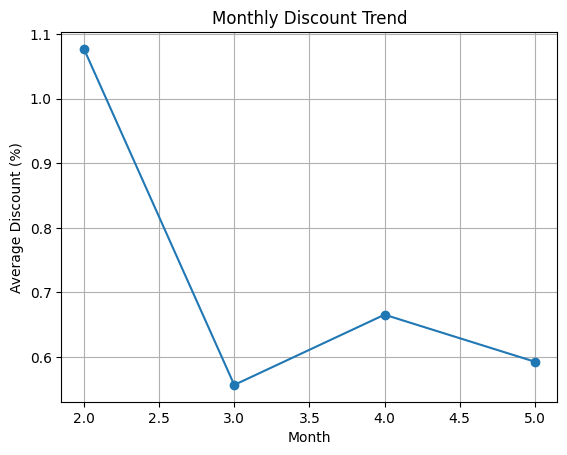

In [113]:
# 1. Monthly Discount Trend
plt.figure()
plt.plot(monthly_trend['Month'], monthly_trend['corrected_Depth%'], marker='o')
plt.title("Monthly Discount Trend")
plt.xlabel("Month")
plt.ylabel("Average Discount (%)")
plt.grid()
plt.show()

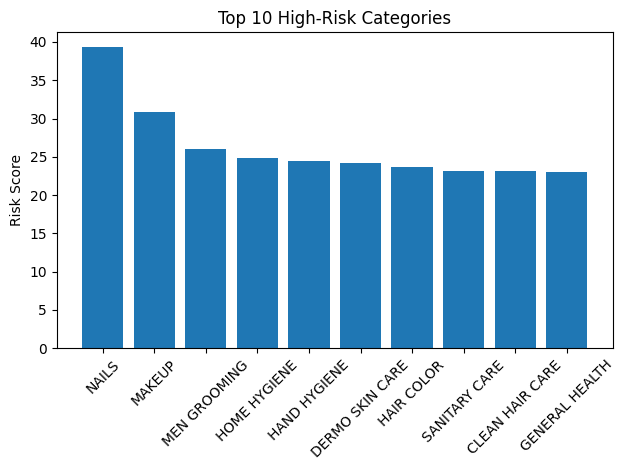

In [114]:
# 2. Top 10 Risky Categories
top_risk = category_analysis.head(10)

plt.figure()
plt.bar(top_risk['Category'], top_risk['Promo_Risk_Score'])
plt.title("Top 10 High-Risk Categories")
plt.xticks(rotation=45)
plt.ylabel("Risk Score")
plt.tight_layout()
plt.show()


RECOMMENDATIONS:


1. Shift from Volume-Driven to Profit-Driven Promotions
Introduce margin guardrails for all campaigns
Avoid deep discounting without clear ROI justification
2. Optimize Discount Depth
Identify and enforce optimal discount brands per category
Reduce unnecessary over-discounting
3. Prioritize High-Margin Categories
Focus promotions on products that:
Can absorb discounts
Drive profitable basket expansion
4. Implement Promotion Performance Dashboard
Track in real-time:
Revenue vs margin impact
Discount efficiency
Category performance
5. Move Toward Data-Driven Personalization (Future Scope)
Transition from blanket promotions to:
Targeted offers

